In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
import pandas as pd

df = pd.read_csv("../data/online_retail_clean.csv")

In [3]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Month', 'Sales'],
      dtype='object')

In [4]:
import datetime as dt

# Make sure InvoiceDate is datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Snapshot date (one day after the last purchase)
snapshot_date = df["InvoiceDate"].max() + dt.timedelta(days=1)

# Create RFM table
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Sales": "sum"
})

# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [5]:
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,4312.00,4312.00,4312.00
mean,91.17,4.46,2040.41
std,96.86,8.17,8911.76
min,1.00,1.00,2.95
25%,18.00,1.00,307.19
50%,53.00,2.00,701.62
75%,136.00,5.00,1714.93
max,374.00,205.00,349164.35


In [6]:
print("Number of customers:", rfm.shape[0])

Number of customers: 4312


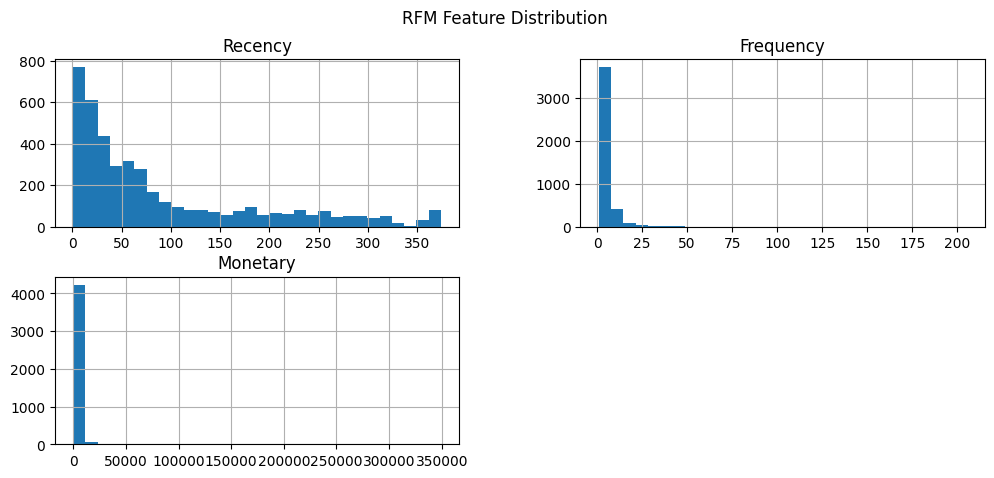

In [7]:
rfm[["Recency", "Frequency", "Monetary"]].hist(
    figsize=(12, 5),
    bins=30
)

plt.suptitle("RFM Feature Distribution")
plt.show()

In [8]:
for column in ["Recency", "Frequency", "Monetary"]:
    lower = rfm[column].quantile(0.01)
    upper = rfm[column].quantile(0.99)

    rfm[column] = rfm[column].clip(lower, upper)

In [9]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.137987,4.126160,1656.856389
std,96.762984,4.909465,2894.379585
min,1.000000,1.000000,40.586400
25%,18.000000,1.000000,307.187500
50%,53.000000,2.000000,701.615000
75%,136.000000,5.000000,1714.932500
max,368.000000,31.000000,20004.390600


In [10]:
rfm_features = rfm[[
    "Recency",
    "Frequency",
    "Monetary"
]]

In [11]:
rfm_features.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [12]:
# Cell 12: Scale ONLY the 3 RFM features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# Verify shape has exactly 3 columns:
print("rfm_scaled shape:", rfm_scaled.shape)  # Should print (4312, 3)

rfm_scaled shape: (4312, 3)


In [13]:
rfm_scaled[:5]

array([[ 0.76341774,  1.40028246, -0.44366859],
       [-0.91097034, -0.43312381, -0.11524925],
       [-0.17713359, -0.63683561, -0.49574105],
       [-0.49754118, -0.229412  ,  0.35047277],
       [-0.82828451, -0.63683561, -0.46852308]])

In [14]:
inertia = []
silhouette_scores = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    inertia.append(kmeans.inertia_)

    silhouette_scores.append(
        silhouette_score(rfm_scaled, labels)
    )

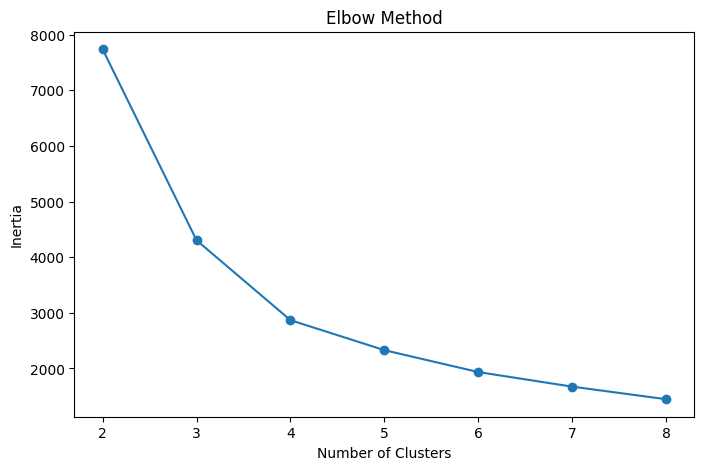

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 9),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

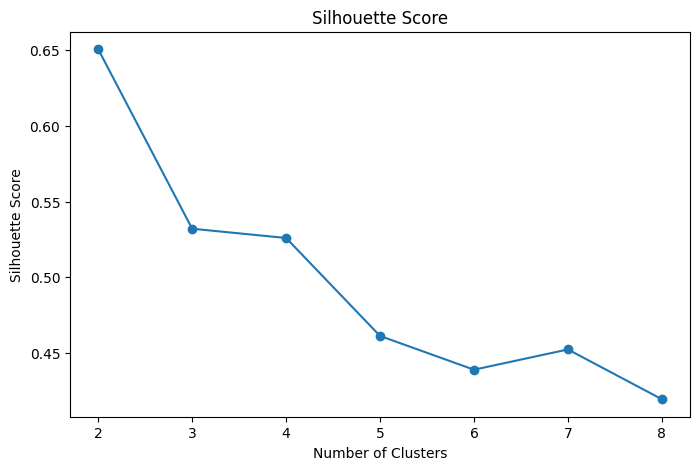

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 9),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")

plt.show()

# Train Final K-Means Model

In [17]:
best_k=4
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [18]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,165,11,372.86,2
12347.0,3,2,1323.32,1
12348.0,74,1,222.16,1
12349.0,43,3,2671.14,1
12351.0,11,1,300.93,1


In [19]:
rfm["Cluster"].value_counts().sort_index()


Cluster
0     111
1    2573
2     626
3    1002
Name: count, dtype: int64

# Analyze the Clusters

In [20]:
# Cell 22: Inspect average metrics per cluster
cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
display(cluster_summary)

,Recency,Frequency,Monetary
Cluster,,,
0,18.28,24.08,15639.89
1,49.39,2.77,889.94
2,26.64,10.20,4175.18
3,246.70,1.60,503.85


In [21]:
# Cell 23 & 24: Map Cluster IDs to Segment Names
cluster_names = {
    0: "VIP Customers",
    1: "Regular Customers",
    2: "Loyal High-Value Customers",
    3: "At-Risk Customers"
}

rfm["Customer Segment"] = rfm["Cluster"].map(cluster_names)

In [22]:
rfm["Customer Segment"] = rfm["Cluster"].map(cluster_names)

In [23]:
rfm[["Recency", "Frequency", "Monetary", "Cluster", "Customer Segment"]].head(10)

,Recency,Frequency,Monetary,Cluster,Customer Segment
Customer ID,,,,,
12346.0,165,11,372.86,2,Loyal High-Value Customers
12347.0,3,2,1323.32,1,Regular Customers
12348.0,74,1,222.16,1,Regular Customers
12349.0,43,3,2671.14,1,Regular Customers
12351.0,11,1,300.93,1,Regular Customers
12352.0,11,2,343.80,1,Regular Customers
12353.0,44,1,317.76,1,Regular Customers
12355.0,203,1,488.21,3,At-Risk Customers
12356.0,16,3,3560.30,1,Regular Customers


In [24]:
rfm["Customer Segment"].value_counts()

Customer Segment
Regular Customers             2573
At-Risk Customers             1002
Loyal High-Value Customers     626
VIP Customers                  111
Name: count, dtype: int64

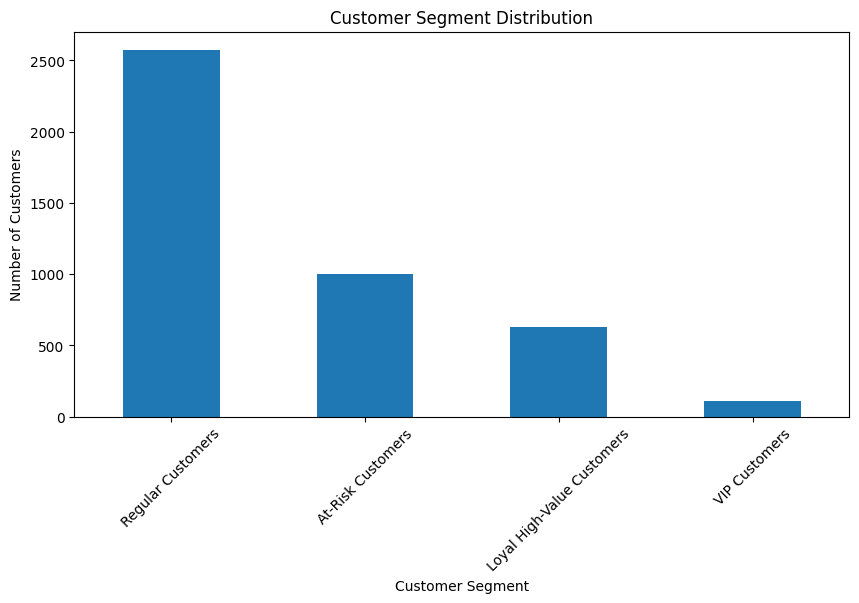

In [25]:
rfm["Customer Segment"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.show()

# Customer Segmentation Visualization

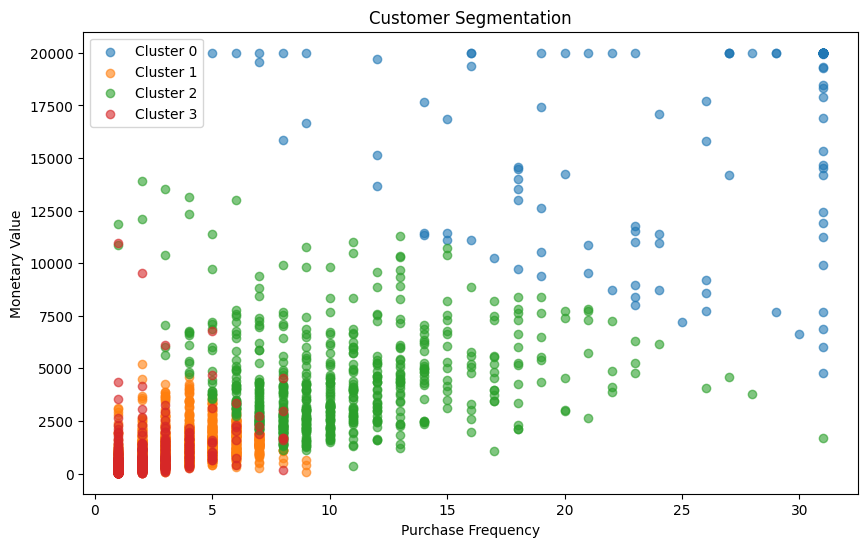

In [26]:
plt.figure(figsize=(10, 6))

for cluster in sorted(rfm["Cluster"].unique()):

    cluster_data = rfm[rfm["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Frequency"],
        cluster_data["Monetary"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.title("Customer Segmentation")
plt.legend()

plt.show()

In [27]:
# calculate final silhoutte score
final_silhouette = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Final Silhouette Score:", round(final_silhouette, 3))

Final Silhouette Score: 0.526


In [28]:
rfm.to_csv(
    "../data/customer_segments.csv"
)

In [29]:
import joblib

joblib.dump(
    kmeans,
    "../models/customer_segmentation_kmeans.pkl"
)
joblib.dump(scaler, "../models/rfm_scaler.pkl")
print("Models and data saved successfully with 3 input features!")

Models and data saved successfully with 3 input features!


In [30]:
joblib.dump(
    scaler,
    "../models/rfm_scaler.pkl"
)

['../models/rfm_scaler.pkl']

In [31]:
print("Customers:", len(rfm))
print("Clusters:", rfm["Cluster"].nunique())
print("Silhouette Score:", round(final_silhouette, 3))

Customers: 4312
Clusters: 4
Silhouette Score: 0.526


In [32]:
display(rfm.head(10))

,Recency,Frequency,Monetary,Cluster,Customer Segment
Customer ID,,,,,
12346.0,165,11,372.86,2,Loyal High-Value Customers
12347.0,3,2,1323.32,1,Regular Customers
12348.0,74,1,222.16,1,Regular Customers
12349.0,43,3,2671.14,1,Regular Customers
12351.0,11,1,300.93,1,Regular Customers
12352.0,11,2,343.80,1,Regular Customers
12353.0,44,1,317.76,1,Regular Customers
12355.0,203,1,488.21,3,At-Risk Customers
12356.0,16,3,3560.30,1,Regular Customers


In [33]:
display(cluster_summary)

,Recency,Frequency,Monetary
Cluster,,,
0,18.28,24.08,15639.89
1,49.39,2.77,889.94
2,26.64,10.20,4175.18
3,246.70,1.60,503.85


In [34]:
# ==============================================================================
# 1. CLUSTERING QUALITY METRICS (UNSUPERVISED)
# ==============================================================================
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil_score = silhouette_score(rfm_scaled, rfm["Cluster"])
db_score = davies_bouldin_score(rfm_scaled, rfm["Cluster"])
ch_score = calinski_harabasz_score(rfm_scaled, rfm["Cluster"])

print("--- Unsupervised Clustering Evaluation ---")
print(f"Silhouette Score (Higher is better, >0.5 is strong): {sil_score:.4f}")
print(f"Davies-Bouldin Index (Lower is better):              {db_score:.4f}")
print(f"Calinski-Harabasz Score (Higher is better):         {ch_score:.2f}")

--- Unsupervised Clustering Evaluation ---
Silhouette Score (Higher is better, >0.5 is strong): 0.5259
Davies-Bouldin Index (Lower is better):              0.7078
Calinski-Harabasz Score (Higher is better):         5043.16


Accuracy Score:      99.19%
Weighted F1-Score:   0.9919
Macro F1-Score:      0.9808

--- Detailed Classification Report ---
                            precision    recall  f1-score   support

         At-Risk Customers       0.99      1.00      0.99       201
Loyal High-Value Customers       0.98      0.98      0.98       125
         Regular Customers       1.00      1.00      1.00       515
             VIP Customers       0.95      0.95      0.95        22

                  accuracy                           0.99       863
                 macro avg       0.98      0.98      0.98       863
              weighted avg       0.99      0.99      0.99       863



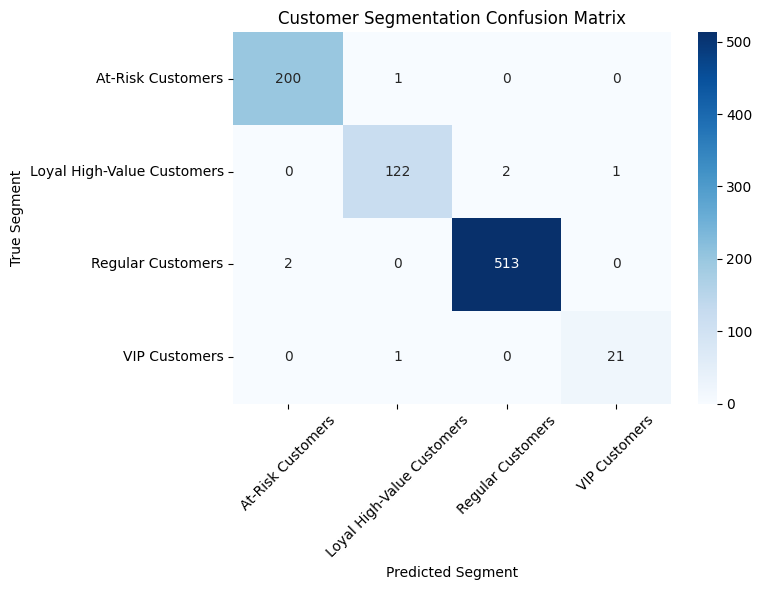

In [38]:
# ==============================================================================
# 2. SUPERVISED EVALUATION: ACCURACY, F1-SCORE & CONFUSION MATRIX
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Features and Target
X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Customer Segment"]

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

# Predict on Unseen Test Set
y_pred = classifier.predict(X_test)

# Calculate Accuracy and F1-Scores
acc = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average="weighted")
f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy Score:      {acc * 100:.2f}%")
print(f"Weighted F1-Score:   {f1_weighted:.4f}")
print(f"Macro F1-Score:      {f1_macro:.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix Heatmap
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Customer Segmentation Confusion Matrix")
plt.xlabel("Predicted Segment")
plt.ylabel("True Segment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()